In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
import celloracle as co
co.__version__

'0.18.0'

In [3]:
# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

In [4]:
#save_folder = "figures"
#os.makedirs(save_folder, exist_ok=True)
data_folder = '../../../data/real/Joung2023/'


In [5]:
###Preparing the data

In [6]:
# This file was already pre-processed according to our analysis on SENA
adata = sc.read_h5ad(data_folder + 'Joung2023.h5ad')  ## Google Drive: gCAL_data > Norman_results
adata

AnnData object with n_obs × n_vars = 460958 × 5000
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime', 'ORF_ID', 'TF_name', 'tmp', 'is_differentiated', 'is_combinatorially_tested', 'control_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [8]:
# making sure to train cell oracle only on the unperturbed data and count values
adata.X = adata.layers['counts'].copy()
adata.obs.rename(columns={"TF_name": "condition"}, inplace=True)
idx = adata.obs.condition == 'ctrl'
adata = adata[idx, :]
adata

View of AnnData object with n_obs × n_vars = 2000 × 5000
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime', 'ORF_ID', 'condition', 'tmp', 'is_differentiated', 'is_combinatorially_tested', 'control_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [11]:
###Analysis

In [10]:
base_GRN = pd.read_parquet(data_folder + 'GRN/' + "hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet") ## Google Drive: gCAL_data > Norman_results

In [14]:
#base_GRN = co.data.load_human_promoter_base_GRN()

In [11]:
base_GRN.head()

,peak_id,gene_short_name,9430076C15RIK,AC002126.6,AC012531.1,AC226150.2,AFP,AHR,AHRR,AIRE,...,ZNF784,ZNF8,ZNF816,ZNF85,ZSCAN10,ZSCAN16,ZSCAN22,ZSCAN26,ZSCAN31,ZSCAN4
0,chr10_100009853_100010953,DNMBP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr10_100081785_100082885,CPN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,chr10_100185877_100186977,ERLIN1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,chr10_100186978_100187057,ERLIN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,chr10_100229510_100230610,CHUK,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
### Make Oracle Object

In [12]:
oracle = co.Oracle()

In [13]:
# Check data in anndata
print("Metadata columns :", list(adata.obs.columns))
print("Dimensional reduction: ", list(adata.obsm.keys()))

Metadata columns : ['TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime', 'ORF_ID', 'condition', 'tmp', 'is_differentiated', 'is_combinatorially_tested', 'control_type']
Dimensional reduction:  ['X_pca', 'X_umap']


In [15]:
adata.obs['cell_type'] = 'hESC'

5000 genes were found in the adata. Note that Celloracle is intended to use around 1000-3000 genes, so the behavior with this number of genes may differ from what is expected.


... storing 'cell_type' as categorical


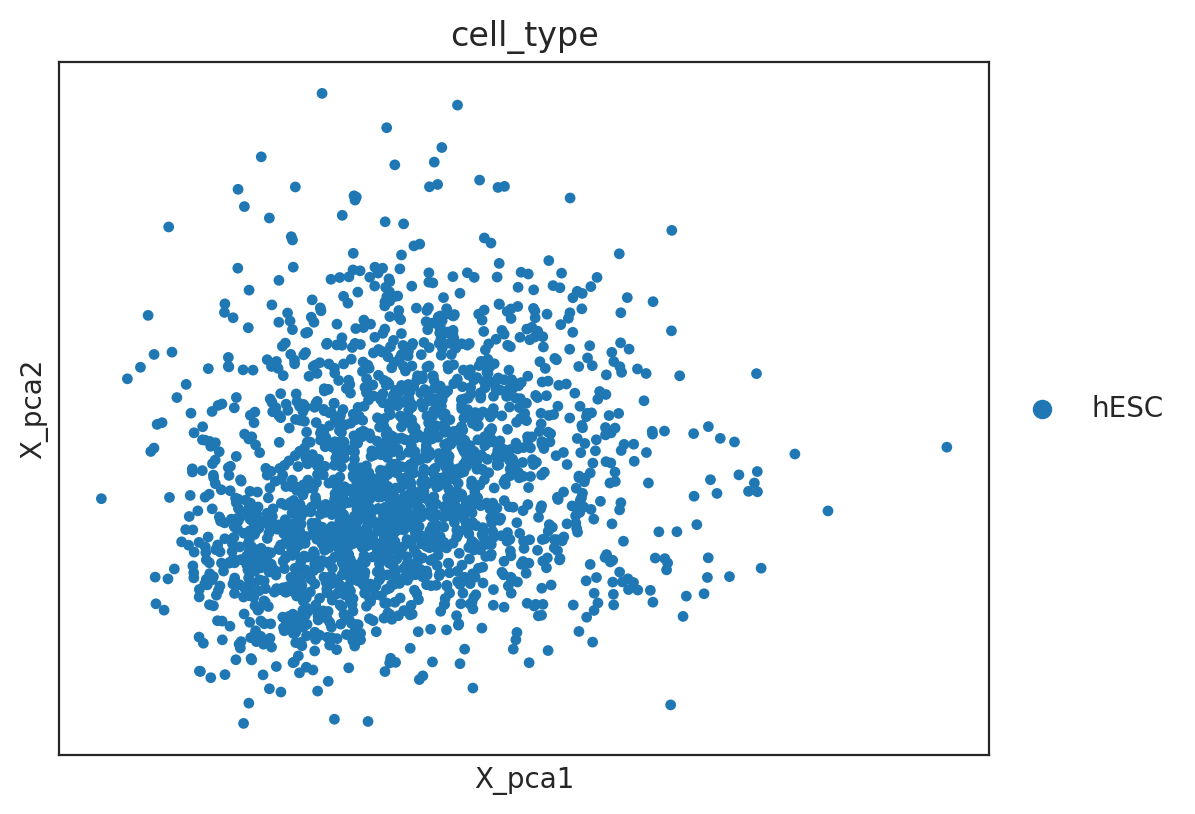

In [16]:
oracle.import_anndata_as_raw_count(adata=adata,
                                   cluster_column_name="cell_type",
                                   embedding_name="X_pca")

In [17]:
oracle.import_TF_data(TF_info_matrix=base_GRN)

In [18]:
##KNN imputation

In [19]:
oracle.perform_PCA()

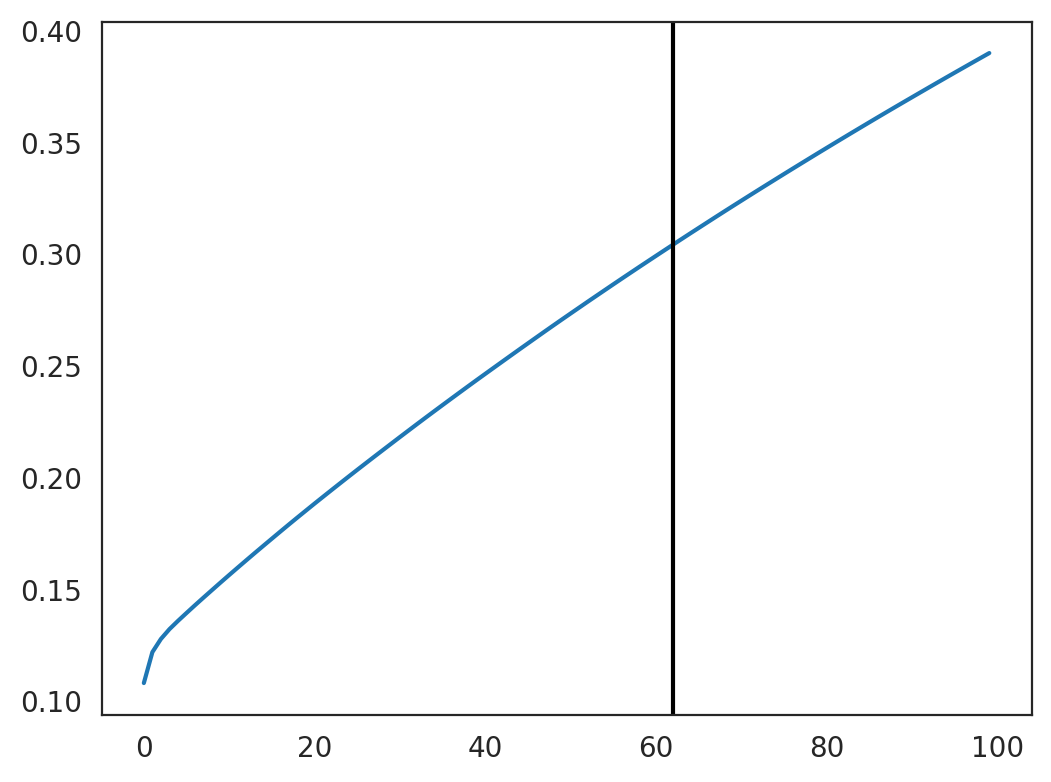

62


In [25]:
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.0025))[0][0]
plt.axvline(n_comps, c="k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)

In [26]:
n_cell = oracle.adata.shape[0]
print(f"cell number is :{n_cell}")

cell number is :2000


In [27]:
k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")

Auto-selected k is :50


In [28]:
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=4)

In [29]:
print(oracle)

Oracle object

Meta data
    celloracle version used for instantiation: 0.18.0
    n_cells: 2000
    n_genes: 5000
    cluster_name: cell_type
    dimensional_reduction_name: X_pca
    n_target_genes_in_TFdict: 27314 genes
    n_regulatory_in_TFdict: 1094 genes
    n_regulatory_in_both_TFdict_and_scRNA-seq: 167 genes
    n_target_genes_both_TFdict_and_scRNA-seq: 2955 genes
    k_for_knn_imputation: 50
Status
    Gene expression matrix: Ready
    BaseGRN: Ready
    PCA calculation: Done
    Knn imputation: Done
    GRN calculation for simulation: Not finished



In [29]:
###Save Oracle Data

In [30]:
#oracle.to_hdf5("Norman2019_oracle_data.celloracle.oracle")

In [31]:
###Load Oracle Data

In [32]:
#oracle = co.load_hdf5("Norman2019_oracle_data.celloracle.oracle")

In [33]:
###GRN calculation

In [30]:
sc.pp.neighbors(oracle.adata)


In [31]:
sc.tl.draw_graph(oracle.adata)


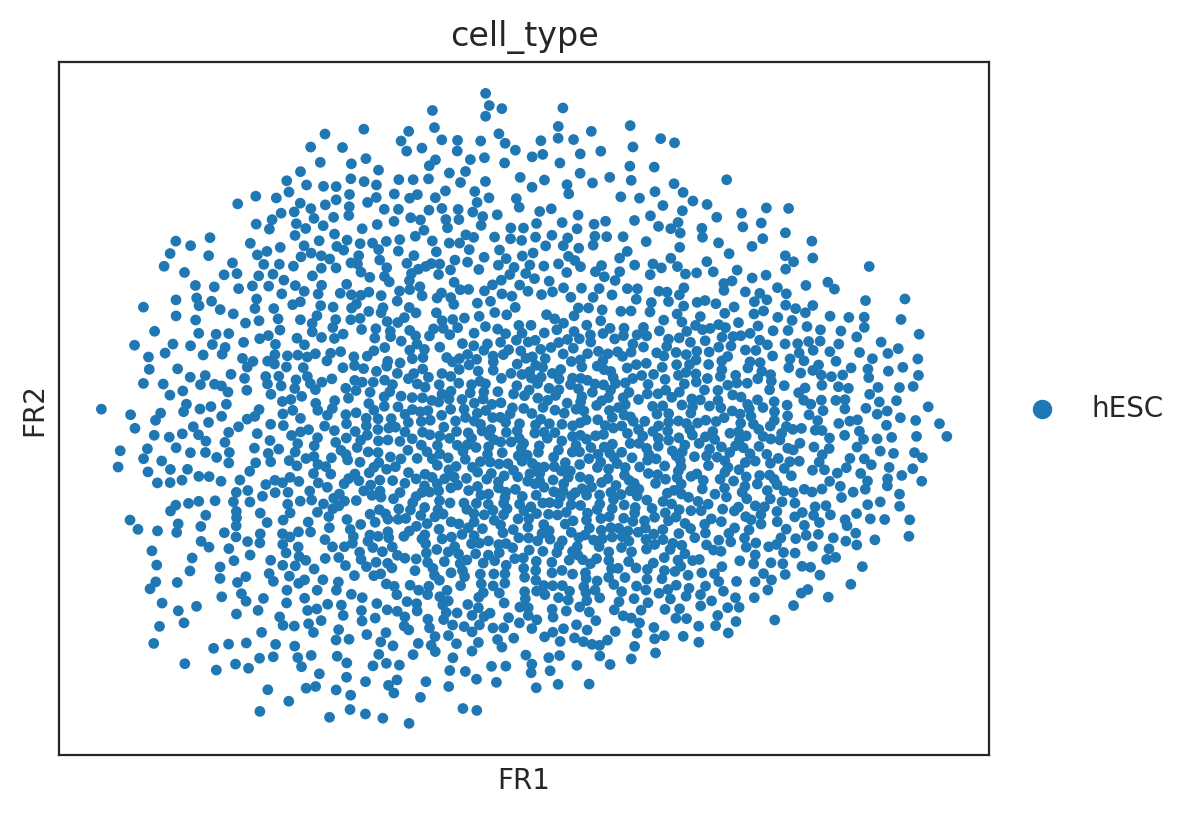

In [32]:
sc.pl.draw_graph(oracle.adata, color="cell_type")

In [33]:
%%time
# Calculate GRN for each population in "louvain_annot" clustering unit.
# This step may take some time.(~30 minutes)
links = oracle.get_links(cluster_name_for_GRN_unit="cell_type", alpha=10,
                         verbose_level=10)

  0%|          | 0/1 [00:00<?, ?it/s]

Inferring GRN for hESC...


  0%|          | 0/2955 [00:00<?, ?it/s]

CPU times: user 2min 13s, sys: 9.87 s, total: 2min 23s
Wall time: 2min 40s


In [34]:
links.links_dict.keys()

dict_keys(['hESC'])

In [35]:
cluster = "hESC"

In [36]:
links.links_dict[cluster].to_csv(data_folder + 'GRN/' + 'raw_GRN.csv')

In [37]:
links.to_hdf5(file_path=data_folder + 'GRN/' + "links.celloracle.links")

In [44]:
##Filtering (which isn't necessary, but the plotting needs it)

In [38]:
links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)

In [39]:
plt.rcParams["figure.figsize"] = [9, 4.5]

hESC


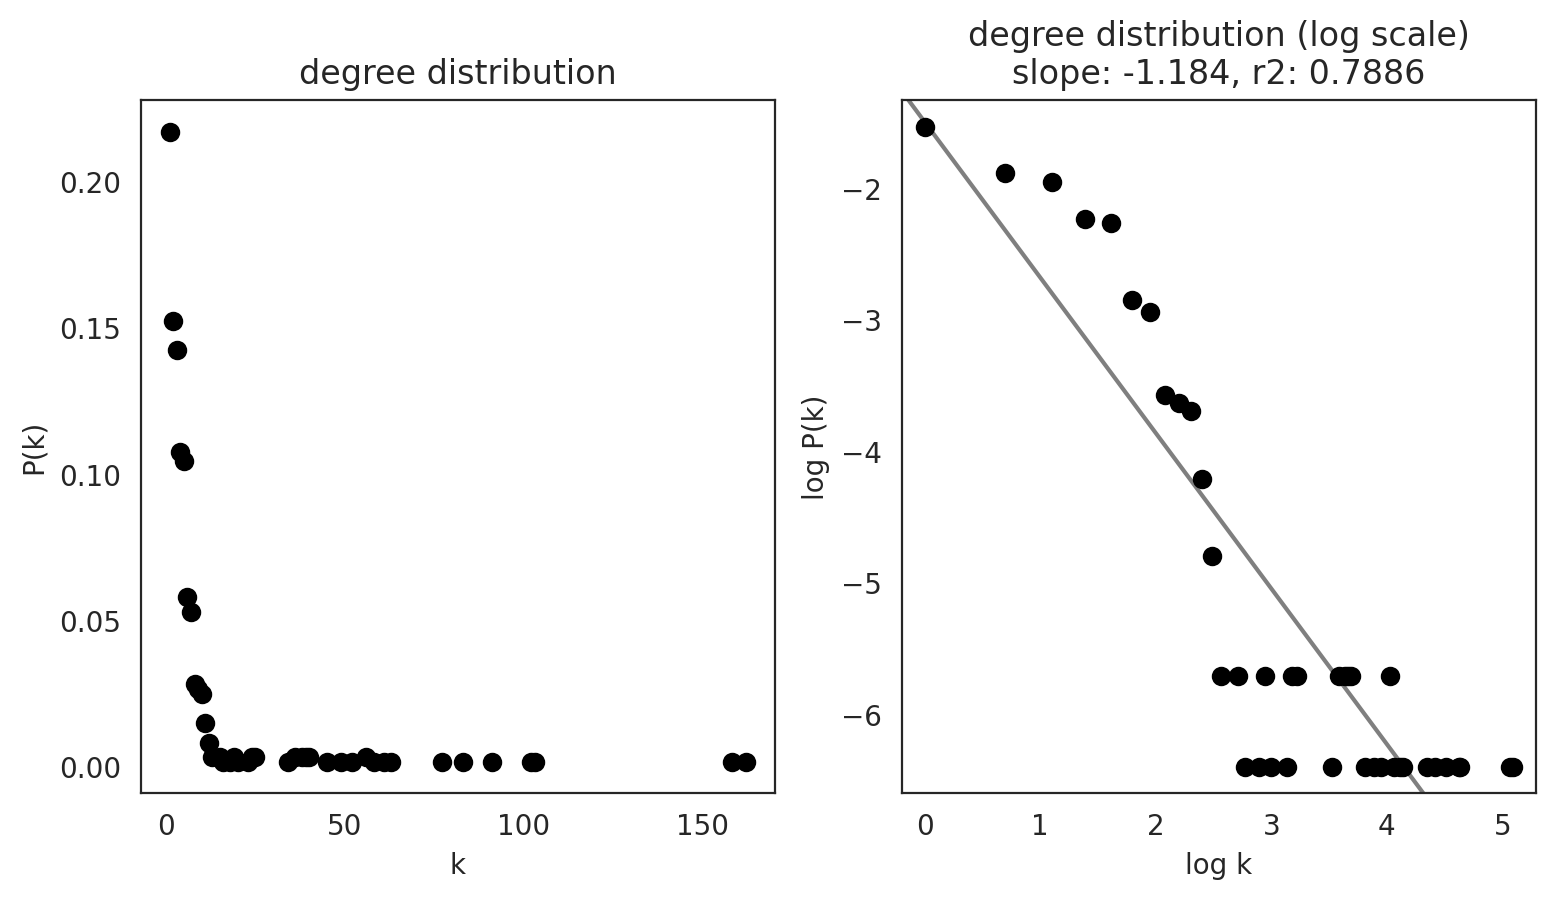

In [40]:
links.plot_degree_distributions(plot_model=True)

In [48]:
##Trying to plot without filtering

Text(0.5, 1.0, 'degree distribution (log scale)\nslope: -0.808, r2: 0.207')

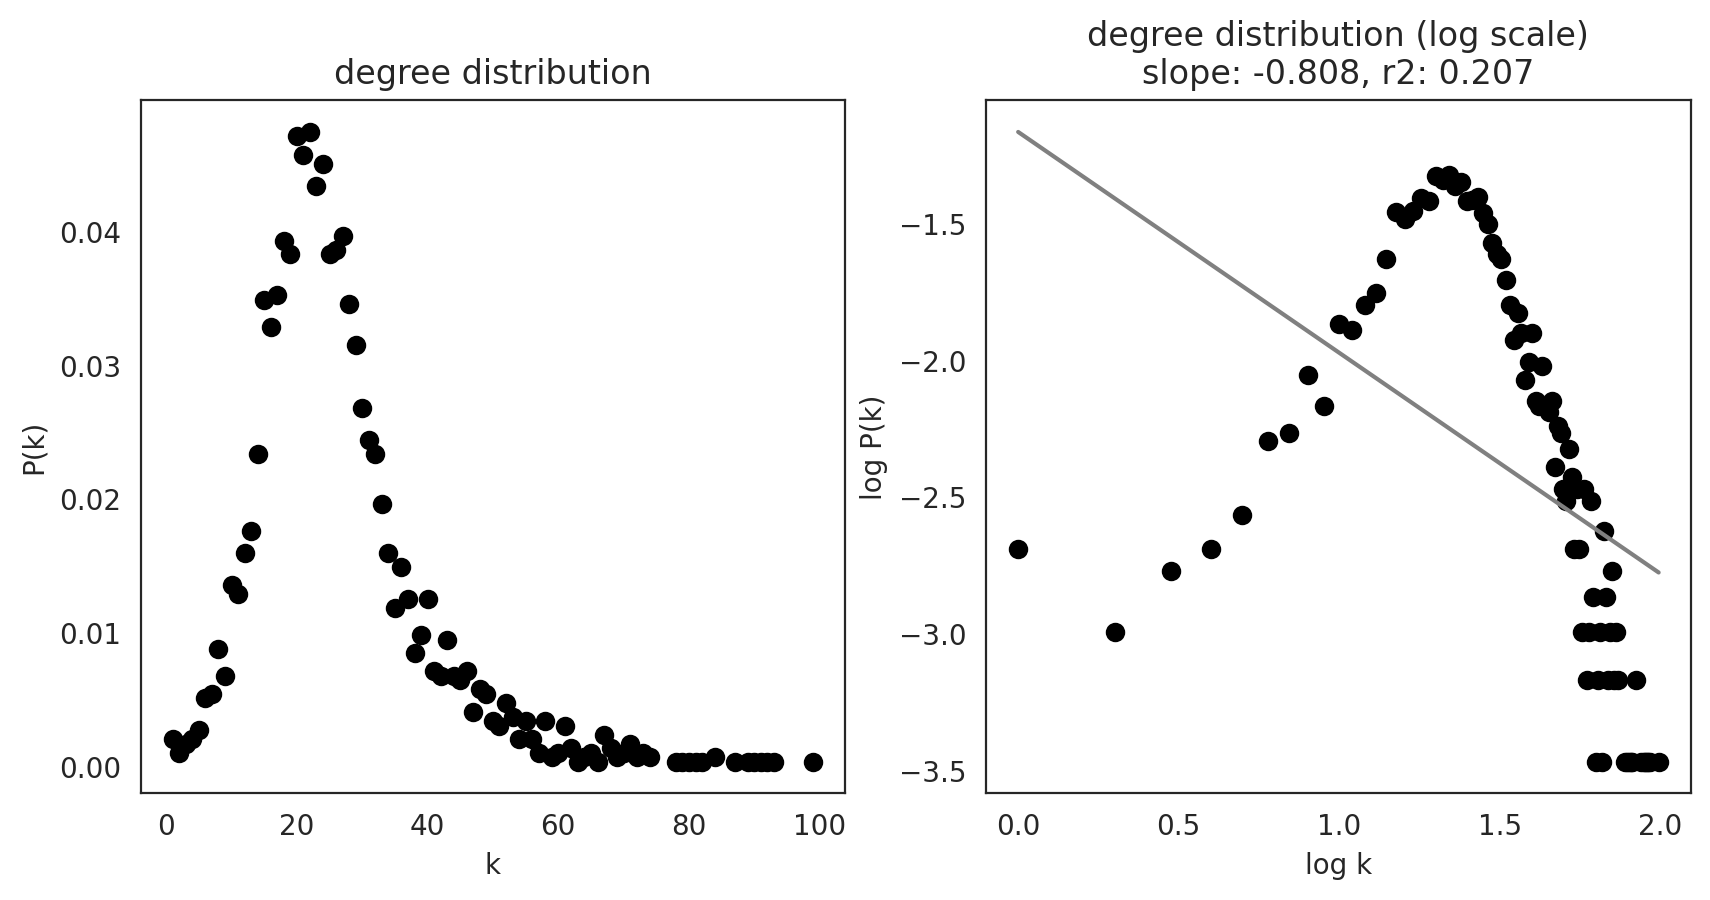

In [41]:
raw_grn_df = links.links_dict["hESC"]

# Step 2: Compute in-degree (number of TFs targeting each gene)
in_deg = raw_grn_df["target"].value_counts()
deg_freq = in_deg.value_counts().sort_index()
probability = deg_freq / deg_freq.sum()

# Step 3: Prepare log-log values for linear fit
log_k = np.log10(deg_freq.index)
log_p = np.log10(probability)

slope, intercept = np.polyfit(log_k, log_p, 1)
r2 = np.corrcoef(log_k, log_p)[0, 1] ** 2

# Step 4: Plot
plt.figure(figsize=(10, 4.5))

# Left panel: degree distribution
plt.subplot(1, 2, 1)
plt.scatter(deg_freq.index, probability, color='black')
plt.xlabel("k")
plt.ylabel("P(k)")
plt.title("degree distribution")

# Right panel: log-log plot
plt.subplot(1, 2, 2)
plt.scatter(log_k, log_p, color='black')
plt.plot(log_k, slope * log_k + intercept, color='gray')
plt.xlabel("log k")
plt.ylabel("log P(k)")
plt.title(f"degree distribution (log scale)\nslope: {slope:.3f}, r2: {r2:.3f}")


In [50]:
##Network scores on filtered data

In [42]:
links.get_network_score()

In [43]:
links.merged_score.head()

,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
GLI2,52,0.086235,4,0.006633,48,0.079602,1582.0,0.235462,hESC
HIST1H2AG,2,0.003317,2,0.003317,0,0.000000,0.0,0.060415,hESC
FOXO3,25,0.041459,0,0.000000,25,0.041459,0.0,0.165975,hESC
HIST1H4E,4,0.006633,4,0.006633,0,0.000000,0.0,0.051042,hESC
ZNF423,37,0.061360,3,0.004975,34,0.056385,2541.0,0.224400,hESC


In [44]:
##Visualize genes with high Centrality

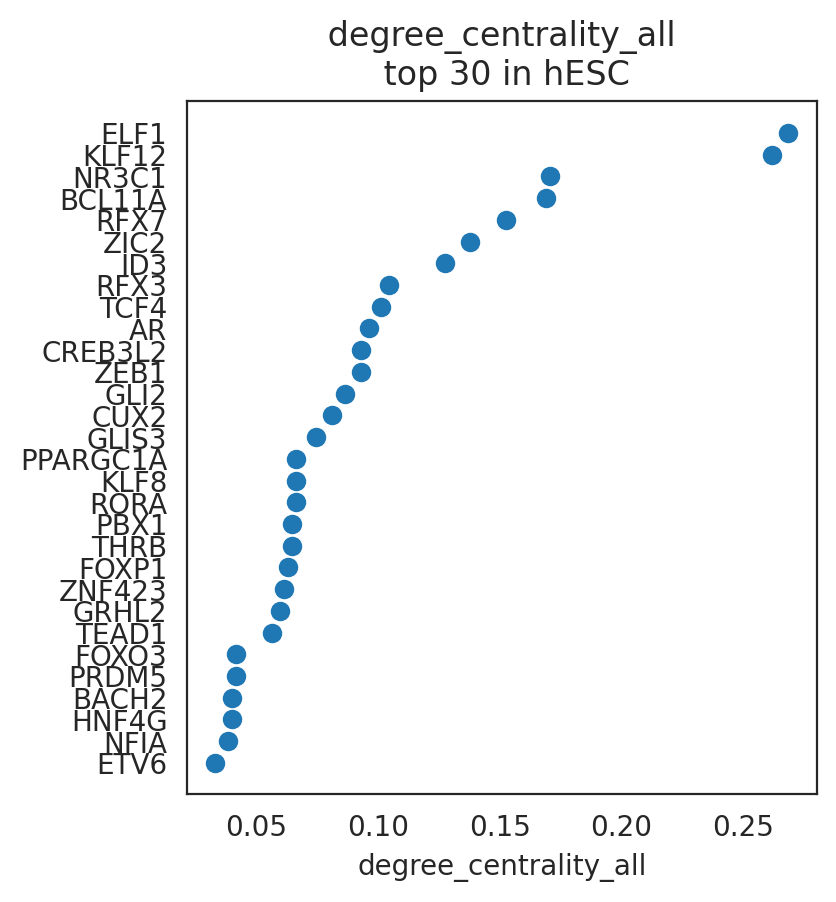

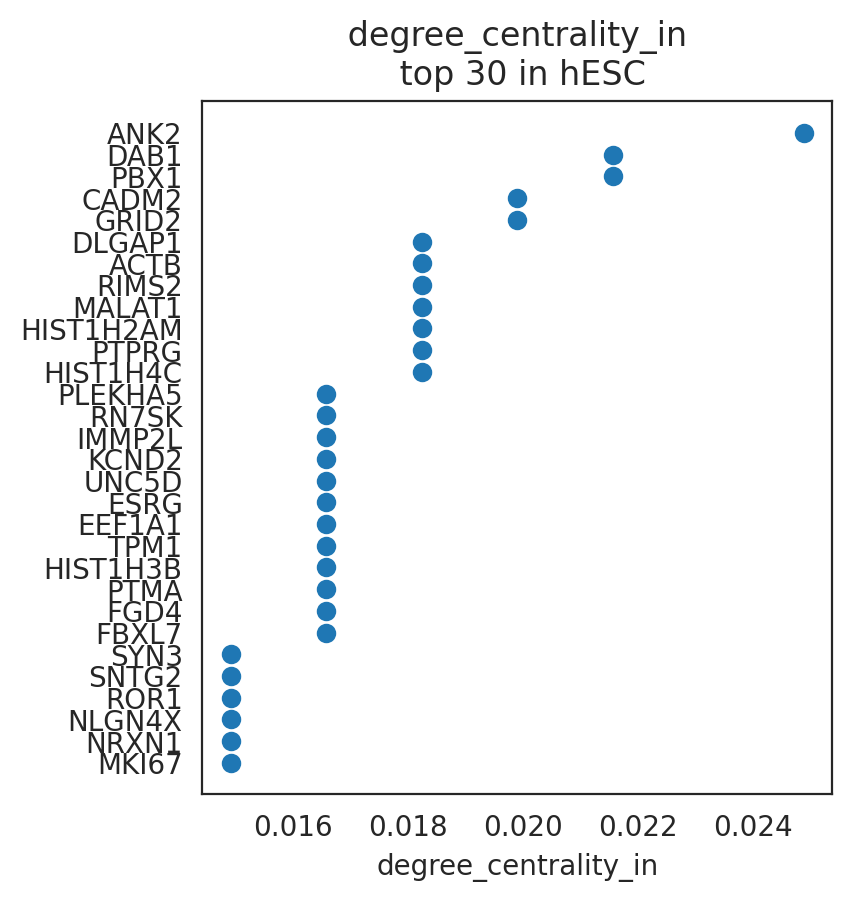

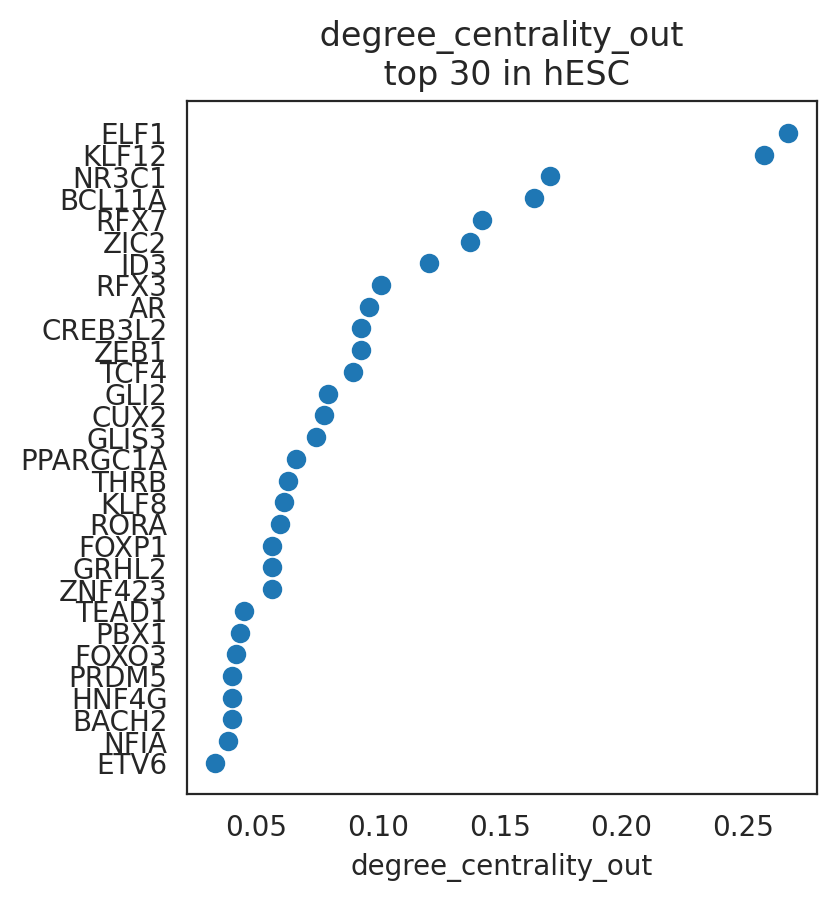

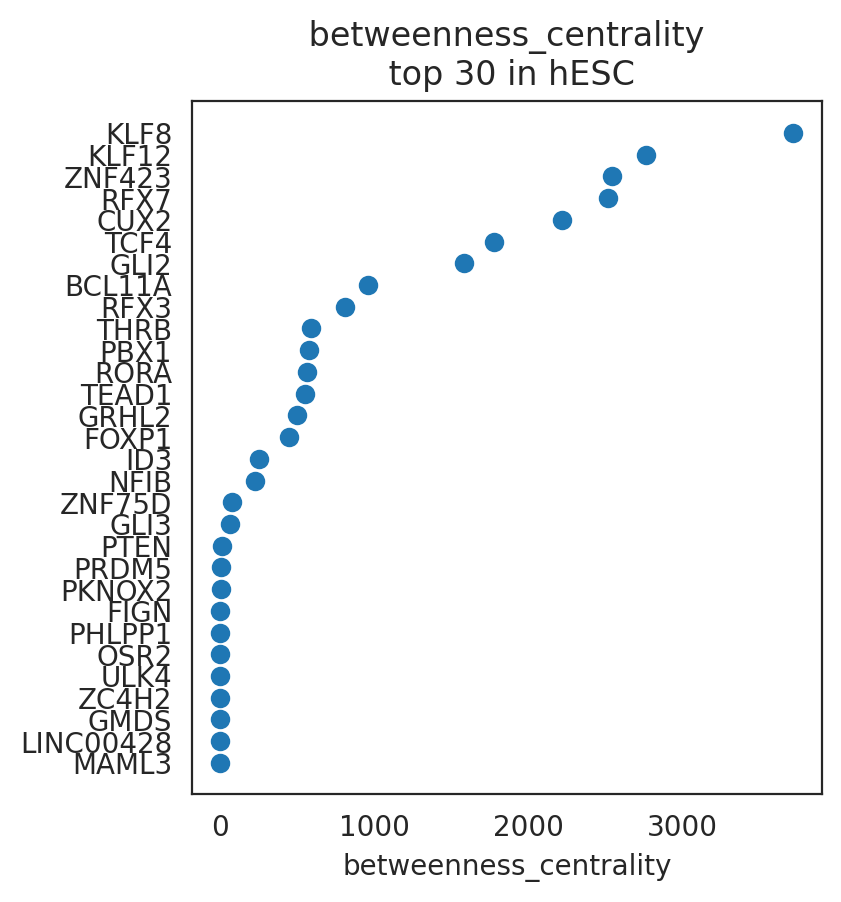

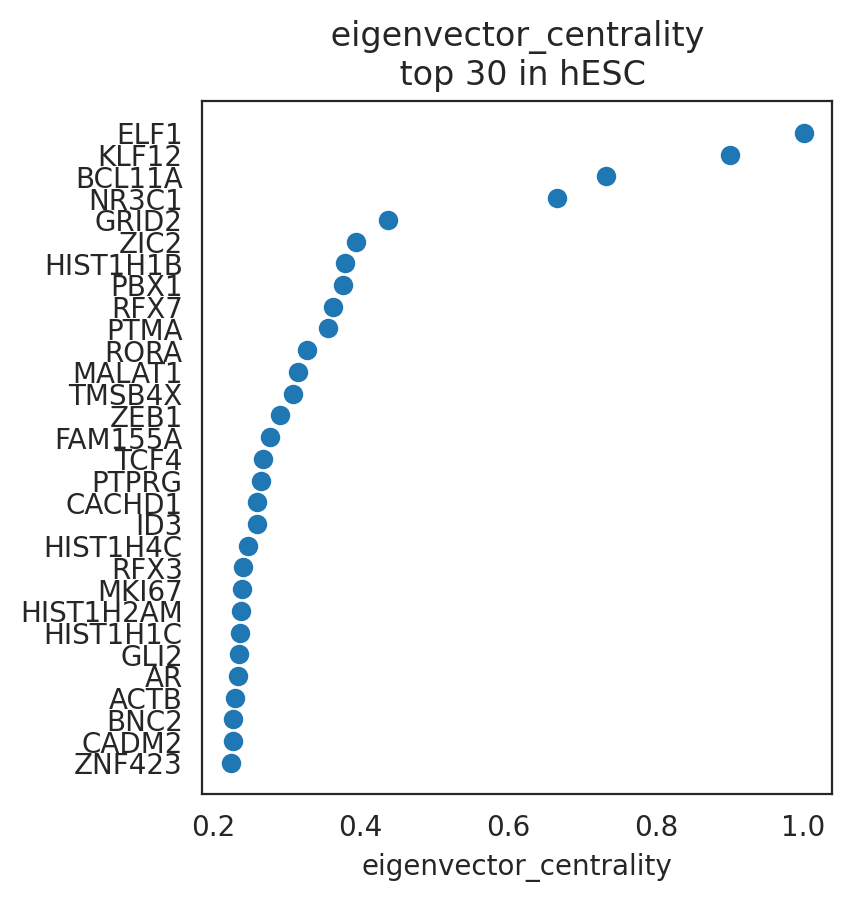

In [46]:
links.plot_scores_as_rank(cluster="hESC", n_gene=30)